In [18]:
import pandas as pd
from cdc_ml.config import POLLS_PROCESSED, CUSTOMER_CLASS_PROCESSED
from cdc_ml.config import POLLS_PROCESSED,CUSTOMER_CLASS_PROCESSED
from cdc_ml.features.build_features import assign_class_type
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [19]:
df = pd.read_parquet(POLLS_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)
df = assign_class_type(df,df_class)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32909 entries, 0 to 32908
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype                         
---  ------             --------------  -----                         
 0   id                 32909 non-null  int64                         
 1   username           32909 non-null  str                           
 2   cycle_start        32909 non-null  datetime64[ns, Asia/Singapore]
 3   cycle_end          32909 non-null  datetime64[ns, Asia/Singapore]
 4   polling_at         32909 non-null  datetime64[ns, Asia/Singapore]
 5   booking_hour       522 non-null    datetime64[ns, Asia/Singapore]
 6   has_booking        32909 non-null  bool                          
 7   cycle_start_month  32909 non-null  int32                         
 8   cycle_start_day    32909 non-null  int32                         
 9   cycle_start_dow    32909 non-null  int32                         
 10  cycle_start_hour   32909 non-null  int32     

In [21]:
df.tail()

,id,username,cycle_start,cycle_end,polling_at,booking_hour,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle,class_type,is_one_team
32904,32607,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 19:00:00+08:00,NaT,False,3,30,0,10,4,13,0,19,345.0,1,1
32905,32608,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 20:00:00+08:00,NaT,False,3,30,0,10,4,13,0,20,346.0,1,1
32906,32609,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 21:00:00+08:00,NaT,False,3,30,0,10,4,13,0,21,347.0,1,1
32907,32610,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 22:00:00+08:00,NaT,False,3,30,0,10,4,13,0,22,348.0,1,1
32908,32611,tomato,2026-03-30 10:00:00+08:00,2026-04-13 23:59:00+08:00,2026-04-13 23:00:00+08:00,NaT,False,3,30,0,10,4,13,0,23,349.0,1,1


In [22]:
#df = df.loc[~(df["username"]=="anmol")]

In [23]:
counts = df["has_booking"].value_counts()
shares = df["has_booking"].value_counts(normalize=True)

tp = pd.concat([counts, shares], axis=1)
tp.columns = ["count", "share"]

In [24]:
tp

,count,share
has_booking,,
False,32387,0.984138
True,522,0.015862


In [25]:
def eda_label_rate(x):
    label_rate = (
        df.groupby(x)["has_booking"]
        .agg(share="mean", count="count")
        .reset_index()
    )
    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Top: label rate with 95% CI
    sns.barplot(data=df, x=x, y="has_booking", ax=axes[0], errorbar=("ci", 95))
    axes[0].set_ylabel("P(has_booking)")

    # Bottom: exposure per category
    sns.barplot(data=label_rate, x=x, y="count", ax=axes[1], color="steelblue")
    axes[1].set_ylabel("n observations")

    plt.tight_layout()


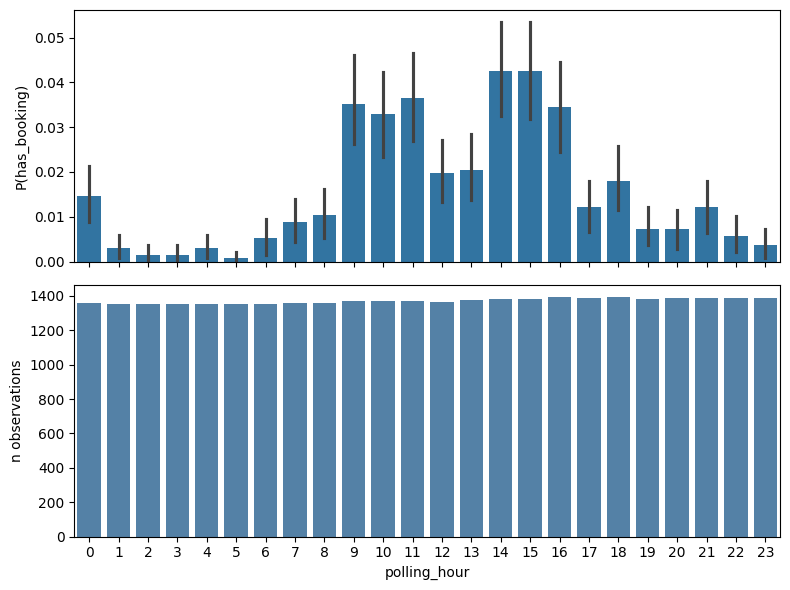

In [26]:
eda_label_rate("polling_hour")

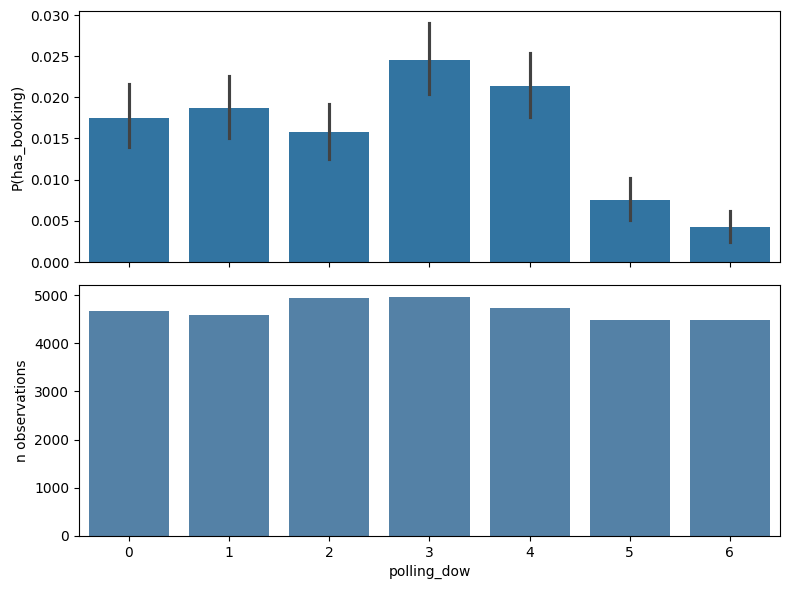

In [27]:
eda_label_rate("polling_dow")

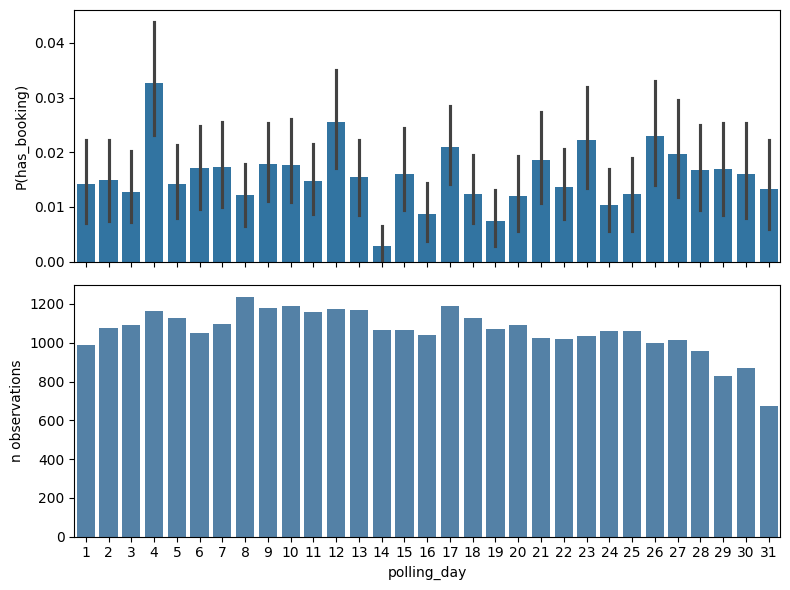

In [28]:
eda_label_rate("polling_day")

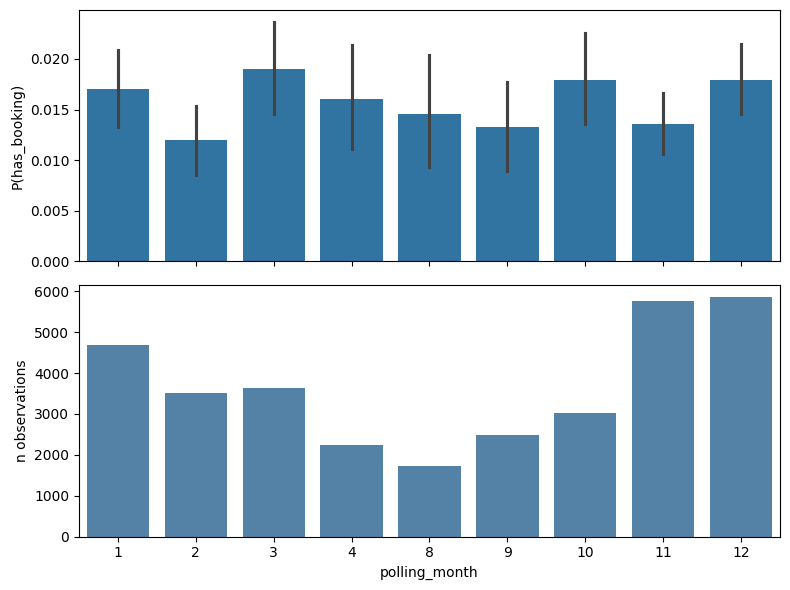

In [29]:
label_rate_by_polling_month = eda_label_rate("polling_month")

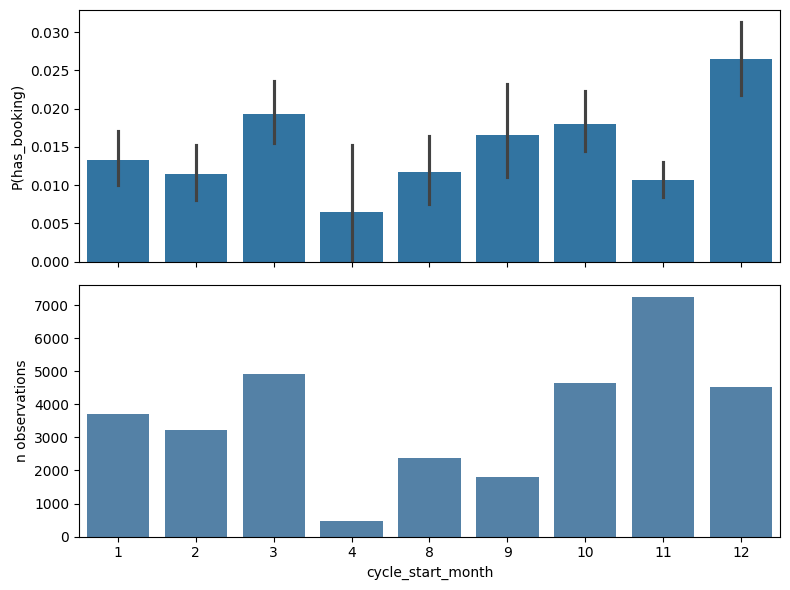

In [30]:
eda_label_rate("cycle_start_month")

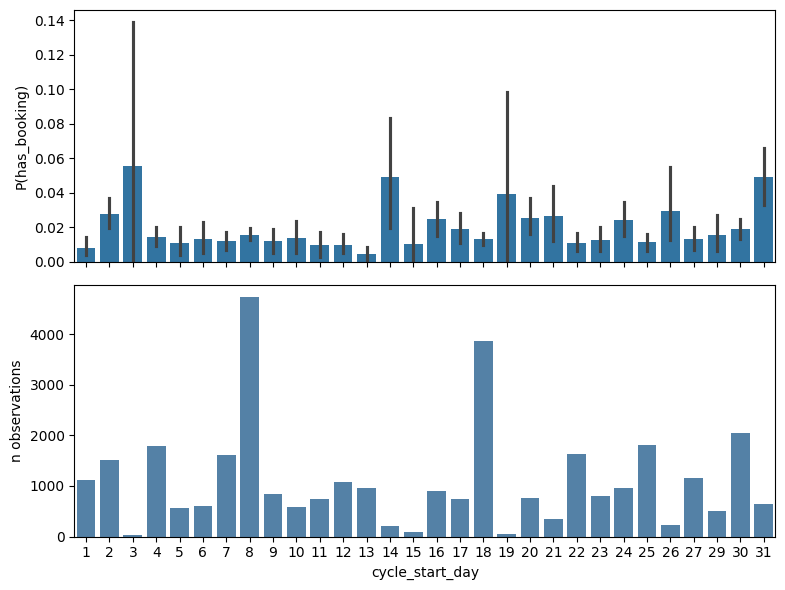

In [31]:
eda_label_rate("cycle_start_day")

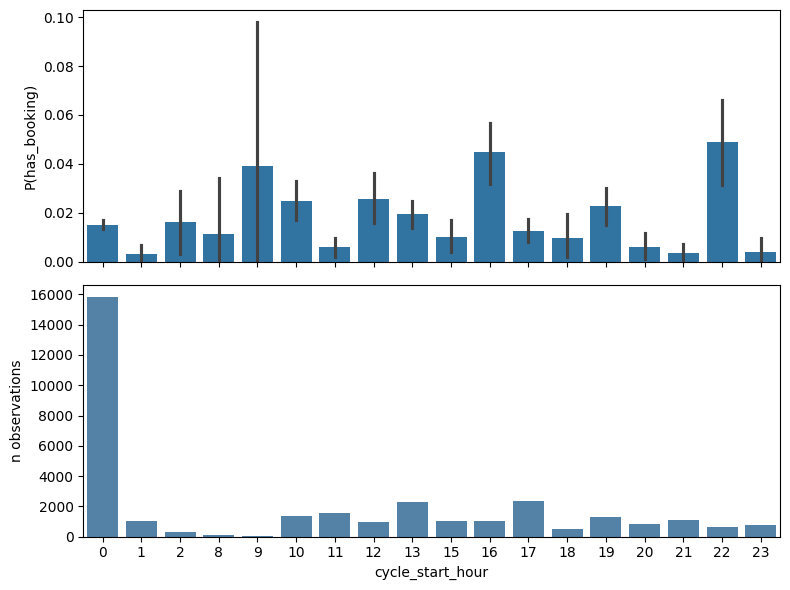

In [32]:
eda_label_rate("cycle_start_hour")

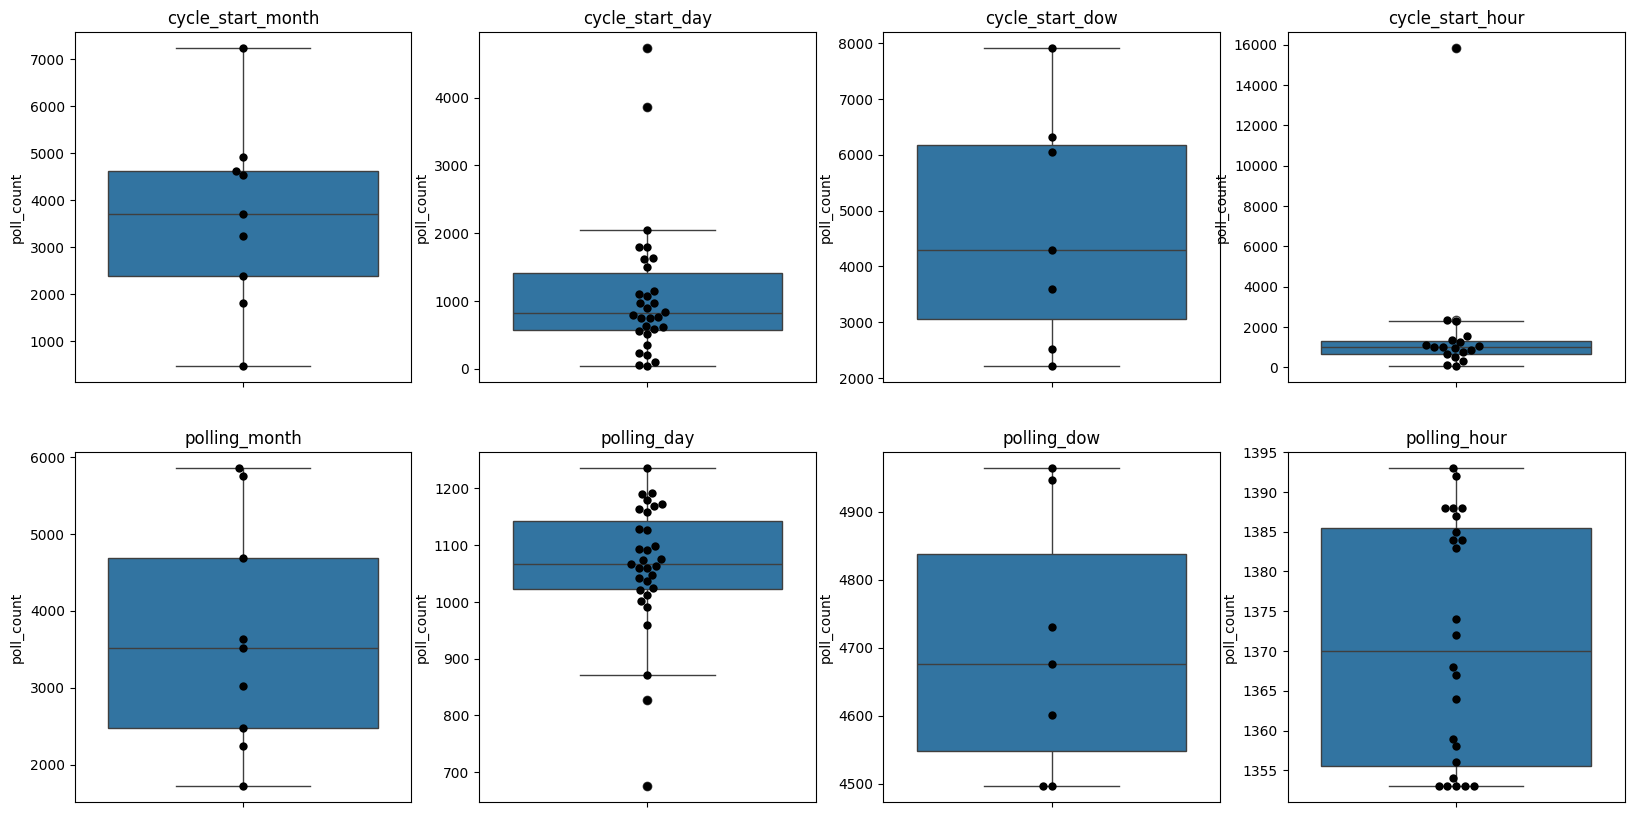

In [33]:
fig,axes = plt.subplots(2,4,figsize=(20,10))

plot_lists = [["cycle_start_month","cycle_start_day","cycle_start_dow","cycle_start_hour",],
              ["polling_month","polling_day","polling_dow","polling_hour"]
              ]

for i in range(2):
    for j in range(4):
        current = plot_lists[i][j]
        count = df.groupby(current)["username"].count().reset_index(name="poll_count")
        sns.boxplot(y=count["poll_count"],ax=axes[i][j])
        sns.swarmplot(y=count["poll_count"], color="black", size=6,ax=axes[i][j])
        axes[i][j].set_title(current)  

In [34]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramer_v_table():
    df = pd.DataFrame({
        "dof":[1,2,3,4,5],
        "small":[.10,.07,.06,.05,.05],
        "medium":[.30,.21,.17,.15,.13],
        "large":[.50,.35,.29,.25,.22]
    })
    return df

def corr_check_chi_v(x,y):
    exact_match = (df[x] == df[y]).mean()
    print(f"Exact match rate: {exact_match:.1%}")

    ct = pd.crosstab(df[x], df[y])
    chi2, p, dof, _ = chi2_contingency(ct)

    n = ct.sum().sum()
    min_dim = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print(f"χ²={chi2:.1f}, p={p:.2e}, Cramér's V={cramers_v:.3f} dof={min_dim} \n")
    print(cramer_v_table())




In [35]:
corr_check_chi_v("cycle_start_month","polling_month")

Exact match rate: 70.4%
χ²=150909.7, p=0.00e+00, Cramér's V=0.757 dof=8 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [36]:
corr_check_chi_v("cycle_start_day","polling_day")

Exact match rate: 6.6%
χ²=30686.6, p=0.00e+00, Cramér's V=0.179 dof=29 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [37]:
corr_check_chi_v("cycle_start_hour","polling_hour")

Exact match rate: 4.3%
χ²=25.9, p=1.00e+00, Cramér's V=0.007 dof=17 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [38]:

corr_check_chi_v("polling_month","polling_day")

Exact match rate: 3.7%
χ²=6783.3, p=0.00e+00, Cramér's V=0.161 dof=8 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [39]:
corr_check_chi_v("polling_day","polling_dow")

Exact match rate: 0.0%
χ²=13273.2, p=0.00e+00, Cramér's V=0.259 dof=6 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [40]:
corr_check_chi_v("polling_dow","polling_hour")

Exact match rate: 4.1%
χ²=3.5, p=1.00e+00, Cramér's V=0.004 dof=6 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [41]:
corr_check_chi_v("polling_dow","has_booking")

Exact match rate: 14.2%
χ²=95.3, p=2.36e-18, Cramér's V=0.054 dof=1 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [42]:

corr_check_chi_v("polling_hour","has_booking")

Exact match rate: 4.1%
χ²=396.3, p=1.05e-69, Cramér's V=0.110 dof=1 

   dof  small  medium  large
0    1   0.10    0.30   0.50
1    2   0.07    0.21   0.35
2    3   0.06    0.17   0.29
3    4   0.05    0.15   0.25
4    5   0.05    0.13   0.22


In [43]:
df["username"].value_counts(normalize=True).sort_values(ascending=False)

username
kim        0.116108
jy         0.071986
flower     0.068917
anmol      0.062810
ryan       0.059771
anaya      0.052569
mya        0.050321
matt       0.047829
ali        0.047100
srpr       0.045793
faith      0.034671
tomato     0.032787
brendon    0.031724
joy        0.025586
jun        0.025525
apple      0.023914
poopie     0.023155
gohguan    0.021453
lucinda    0.018050
natar      0.016774
fir        0.015832
bw         0.014616
addity     0.014586
np         0.012914
bryan      0.010787
d          0.008022
aswath     0.006807
nur        0.006594
phuc       0.006351
carol      0.005834
sara       0.005439
pakning    0.004588
bhara      0.004376
isyaf      0.002218
ajithak    0.001550
max        0.001550
ranjith    0.001094
Name: proportion, dtype: float64

In [44]:
df.groupby(["username"])["has_booking"].sum().sort_values(ascending=False)

username
anmol      109
jy          44
mya         39
poopie      35
jun         30
joy         27
kim         27
srpr        21
tomato      20
flower      18
faith       15
addity      15
lucinda     12
apple       12
bryan        9
anaya        9
ryan         8
brendon      8
aswath       7
ali          6
np           5
matt         5
nur          5
carol        4
sara         4
max          4
phuc         3
fir          3
bhara        3
gohguan      3
pakning      3
ajithak      2
isyaf        2
natar        2
d            1
bw           1
ranjith      1
Name: has_booking, dtype: int64

   username  has_booking
32     ryan         1967
33    anmol         2067
34   flower         2268
35       jy         2369
36      kim         3821


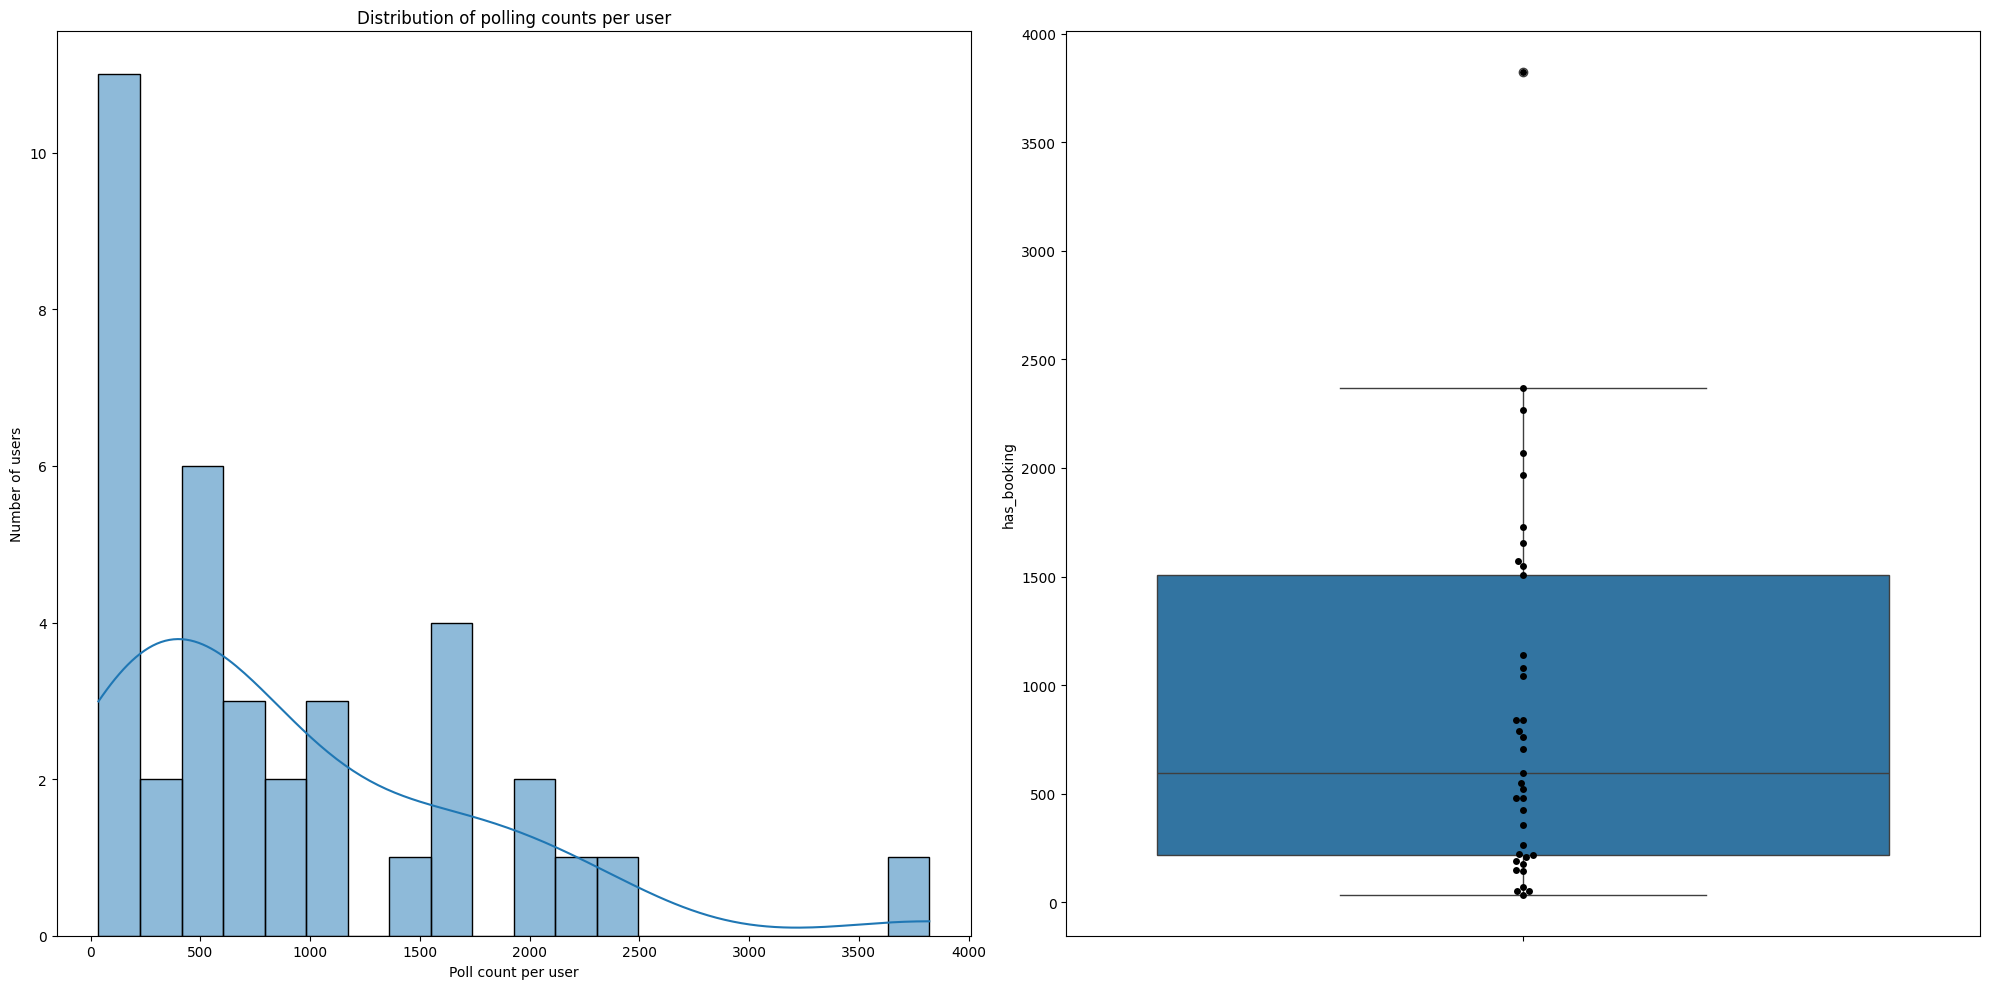

In [45]:
user_distribution = df.groupby("username")["has_booking"].count().sort_values().reset_index()
print(user_distribution.tail())

fig, axes = plt.subplots(1,2,figsize=(20, 10))
sns.histplot(
    data=user_distribution,
    x="has_booking",
    bins=20,
    kde=True,      
    ax=axes[0]
)
axes[0].set_xlabel("Poll count per user")
axes[0].set_ylabel("Number of users")
axes[0].set_title("Distribution of polling counts per user")

sns.boxplot(data=user_distribution,y="has_booking",ax=axes[1])
sns.swarmplot(data=user_distribution,y="has_booking",color="black",ax=axes[1])
plt.tight_layout()
plt.show()

In [46]:
count = df.groupby(["username"])["has_booking"].count().reset_index()
q_25,q_50,q_75 = count["has_booking"].quantile([0.25,0.5,0.75])

iqr = q_75 - q_25
print(q_25,q_50,q_75,iqr)

217.0 594.0 1507.0 1290.0


<Axes: xlabel='poll_count', ylabel='booking_rate'>

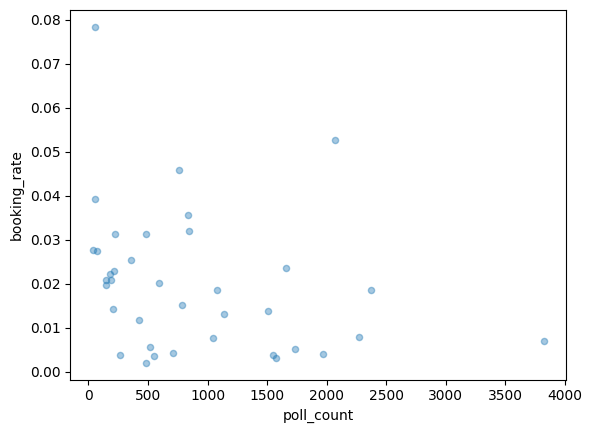

In [47]:
stats = df.groupby("username")["has_booking"].agg(["count", "mean"]).reset_index()
stats.columns = ["username", "poll_count", "booking_rate"]

# Does booking rate correlate with how long they've been observed?
stats.plot.scatter(x="poll_count", y="booking_rate", alpha=0.4)

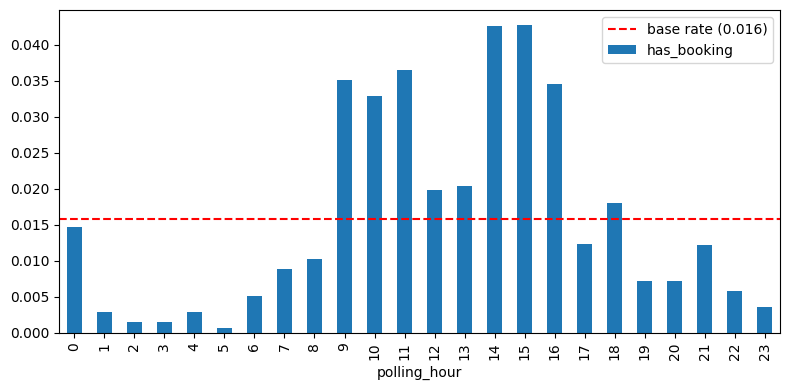

In [48]:
def success_share(x):
    rate = df.groupby(x)["has_booking"].mean()
    base = df["has_booking"].mean()
    
    fig, ax = plt.subplots(figsize=(8, 4))
    rate.plot(kind="bar", ax=ax)
    ax.axhline(base, color="red", linestyle="--", label=f"base rate ({base:.3f})")
    ax.legend()
    plt.tight_layout()
    plt.show()

success_share("polling_hour")


   username  count     share
0       kim   3821  0.116108
1        jy   2369  0.071986
2    flower   2268  0.068917
3     anmol   2067  0.062810
4      ryan   1967  0.059771
5     anaya   1730  0.052569
6       mya   1656  0.050321
7      matt   1574  0.047829
8       ali   1550  0.047100
9      srpr   1507  0.045793
10    faith   1141  0.034671
11   tomato   1079  0.032787
12  brendon   1044  0.031724
13      joy    842  0.025586
14      jun    840  0.025525
15    apple    787  0.023914
16   poopie    762  0.023155
17  gohguan    706  0.021453
18  lucinda    594  0.018050
19    natar    552  0.016774
20      fir    521  0.015832
21       bw    481  0.014616
22   addity    480  0.014586
23       np    425  0.012914
24    bryan    355  0.010787
25        d    264  0.008022
26   aswath    224  0.006807
27      nur    217  0.006594
28     phuc    209  0.006351
29    carol    192  0.005834
30     sara    179  0.005439
31  pakning    151  0.004588
32    bhara    144  0.004376
33    isyaf   

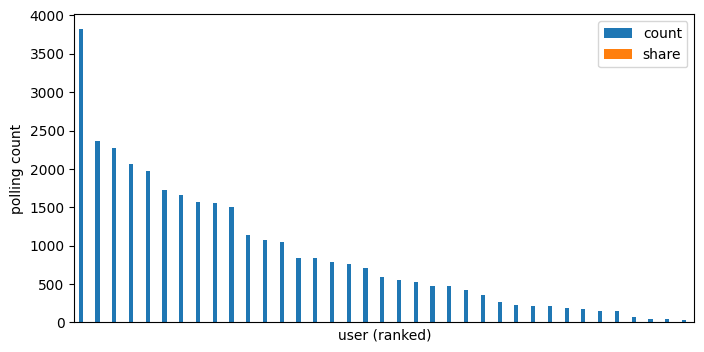

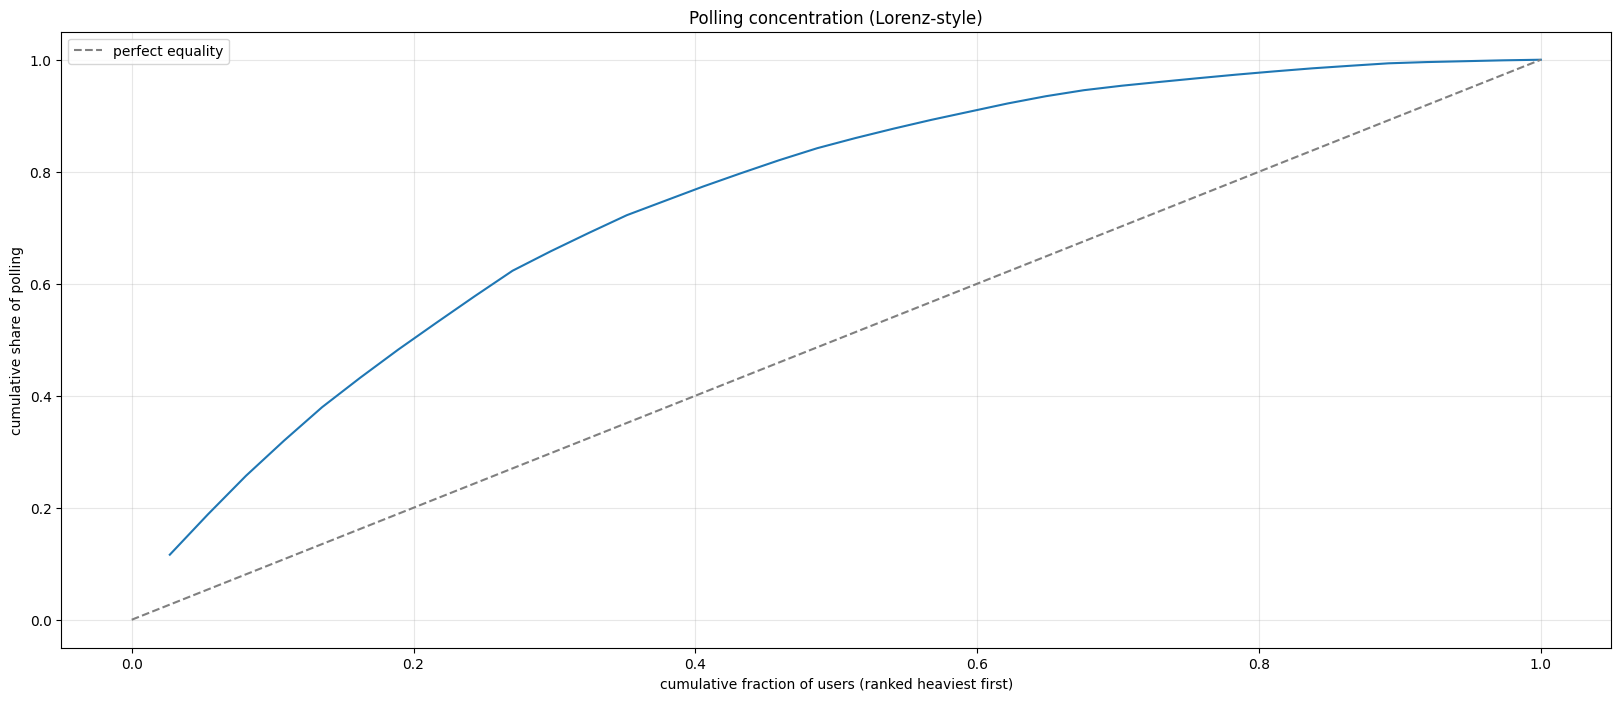

In [49]:
counts = df['username'].value_counts().reset_index().assign(share=lambda x:x["count"]/len(df))
print(counts)

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind='bar', ax=ax)
ax.set_ylabel('polling count')
ax.set_xlabel('user (ranked)')
ax.set_xticks([])  # hide labels if there are many users


counts_sorted = (
    counts.sort_values('share', ascending=False)
          .reset_index(drop=True)
)
counts_sorted['cum_share'] = counts_sorted['share'].cumsum()
counts_sorted['cum_user_frac'] = (counts_sorted.index + 1) / len(counts_sorted)

fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(counts_sorted['cum_user_frac'], counts_sorted['cum_share'])
ax.plot([0, 1], [0, 1], '--', color='gray', label='perfect equality')
ax.set_xlabel('cumulative fraction of users (ranked heaviest first)')
ax.set_ylabel('cumulative share of polling')
ax.set_title('Polling concentration (Lorenz-style)')
ax.grid(True, alpha=0.3)
ax.legend()

for k in [0.05, 0.10, 0.20, 0.50]:
    n = max(1, int(k * len(counts_sorted)))
    print(f'top {k:.0%} of users ({n}) → {counts_sorted["share"].head(n).sum():.1%} of polls')

In [50]:
import numpy as np

def gini(x):
    x = np.sort(np.asarray(x))
    n = len(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * x.sum()) / (n * x.sum())

print(f'Gini: {gini(counts["share"].values):.3f}')

Gini: 0.491


top 5% of users (1) → 11.6% of polls
top 10% of users (3) → 25.7% of polls
top 20% of users (7) → 48.2% of polls
top 50% of users (18) → 84.2% of polls


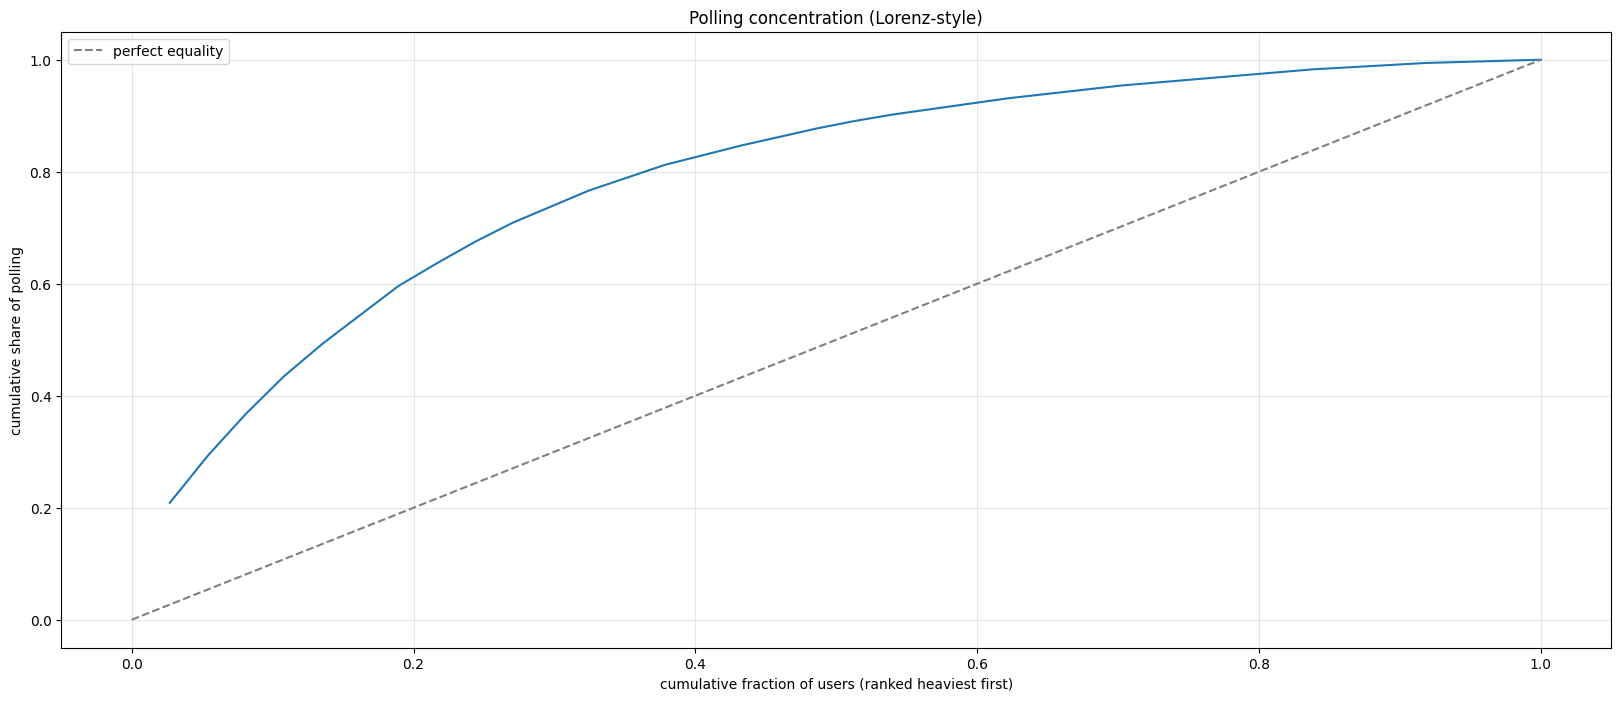

In [51]:
total_sum = df["has_booking"].sum()
whales_sum = df.groupby(["username"])["has_booking"].sum().sort_values(ascending=False).reset_index(name="sum")
whales_sum["share"] = whales_sum["sum"]/total_sum


whales_sum["cum_share"] = whales_sum["share"].cumsum()
whales_sum["cum_frac"] = ((whales_sum.index +1) / len(whales_sum))


fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(whales_sum['cum_frac'], whales_sum['cum_share'])
ax.plot([0, 1], [0, 1], '--', color='gray', label='perfect equality')
ax.set_xlabel('cumulative fraction of users (ranked heaviest first)')
ax.set_ylabel('cumulative share of polling')
ax.set_title('Polling concentration (Lorenz-style)')
ax.grid(True, alpha=0.3)
ax.legend()

for k in [0.05, 0.10, 0.20, 0.50]:
    n = max(1, int(k * len(counts_sorted)))
    print(f'top {k:.0%} of users ({n}) → {counts_sorted["share"].head(n).sum():.1%} of polls')


In [52]:
whales_count = counts_sorted.iloc[:int(0.10*len(whales_sum))]
print(whales_count)

  username  count     share  cum_share  cum_user_frac
0      kim   3821  0.116108   0.116108       0.027027
1       jy   2369  0.071986   0.188094       0.054054
2   flower   2268  0.068917   0.257012       0.081081


In [53]:
whales_positive_share = whales_sum.iloc[:int(0.10*len(whales_sum))]
print(whales_positive_share)

  username  sum     share  cum_share  cum_frac
0    anmol  109  0.208812   0.208812  0.027027
1       jy   44  0.084291   0.293103  0.054054
2      mya   39  0.074713   0.367816  0.081081


JS divergence (positive-location): 0.283   # 0 = identical pattern, 1 = disjoint


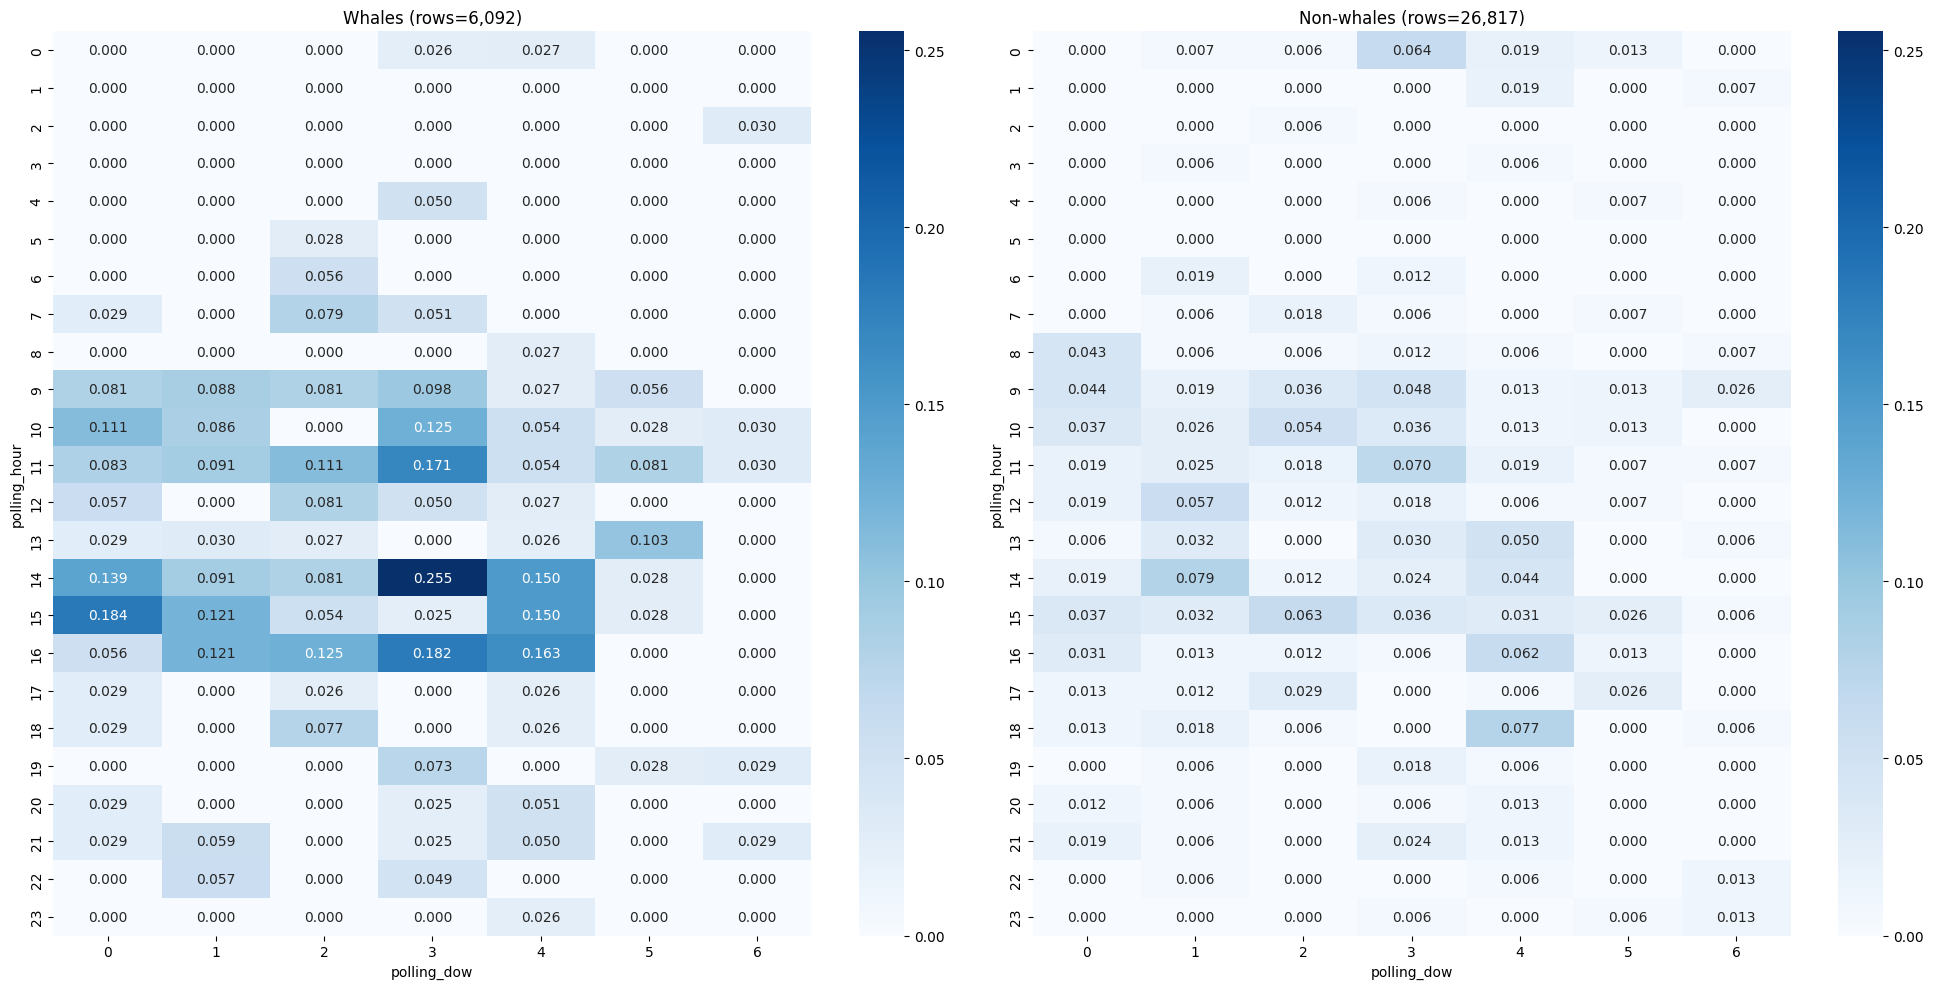

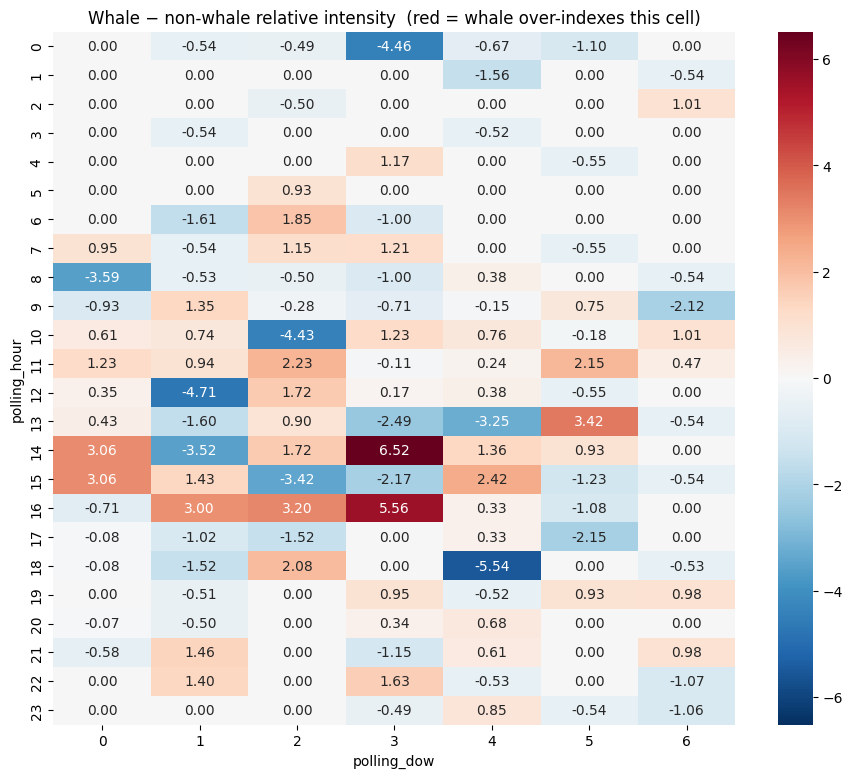

In [54]:
import numpy as np

whales = ["anmol", "jy", "mya"]
is_whale = df["username"].isin(whales)

# Full grid so BOTH heatmaps share identical axes (missing cells -> NaN, not dropped/misaligned)
dows  = sorted(df["polling_dow"].unique())
hours = sorted(df["polling_hour"].unique())

def grid(sub):
    g = sub.groupby(["polling_dow", "polling_hour"])["has_booking"]
    rate    = g.mean().unstack("polling_dow").reindex(index=hours, columns=dows)
    support = g.size().unstack("polling_dow").reindex(index=hours, columns=dows)
    return rate, support

w_rate,  w_support  = grid(df[is_whale])
nw_rate, nw_support = grid(df[~is_whale])

# Mask cells with too few polls to trust the rate (whale side is only 3 users)
MIN_POLLS = 30
w_rate_m  = w_rate.mask(w_support  < MIN_POLLS)
nw_rate_m = nw_rate.mask(nw_support < MIN_POLLS)

# --- FIX 1: shared color scale, so the side-by-side is honest about LEVEL ---
vmax = float(np.nanmax([np.nanmax(w_rate_m.values), np.nanmax(nw_rate_m.values)]))
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
sns.heatmap(w_rate_m,  annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=vmax, ax=axes[0])
sns.heatmap(nw_rate_m, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=vmax, ax=axes[1])
axes[0].set_title(f"Whales (rows={int(is_whale.sum()):,})")
axes[1].set_title(f"Non-whales (rows={int((~is_whale).sum()):,})")
plt.tight_layout()

# --- FIX 2: shape-only difference map, to separate "books more" from "books at different times" ---
w_shape  = w_rate_m  / np.nanmean(w_rate_m.values)     # relative intensity, own mean = 1.0
nw_shape = nw_rate_m / np.nanmean(nw_rate_m.values)
diff = w_shape - nw_shape
fig2, ax2 = plt.subplots(figsize=(11, 9))
lim = float(np.nanmax(np.abs(diff.values)))
sns.heatmap(diff, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=ax2)
ax2.set_title("Whale − non-whale relative intensity  (red = whale over-indexes this cell)")

# --- FIX 3: one number instead of an eyeball — JS divergence of WHERE positives land ---
def booking_dist(sub):  # distribution of positives across cells, counts-based (no support mask needed)
    c = (sub.groupby(["polling_dow","polling_hour"])["has_booking"].sum()
            .unstack("polling_dow").reindex(index=hours, columns=dows).fillna(0).values.ravel())
    return c / c.sum()

p, q = booking_dist(df[is_whale]), booking_dist(df[~is_whale])
m = 0.5 * (p + q)
kl = lambda a, b: np.sum(a[a > 0] * np.log2(a[a > 0] / b[a > 0]))
js = 0.5 * kl(p, m) + 0.5 * kl(q, m)
print(f"JS divergence (positive-location): {js:.3f}   # 0 = identical pattern, 1 = disjoint")

<Axes: xlabel='hours_into_cycle', ylabel='Count'>

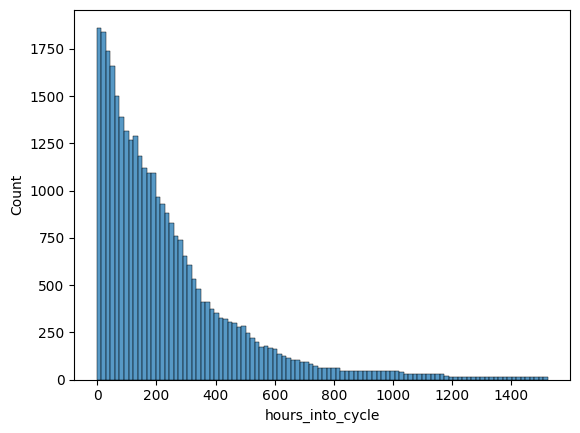

In [55]:
sns.histplot(data=df,x="hours_into_cycle")

    is_one_team             hours_bin  has_booking
0             0     (-2.474, 151.468]     0.016838
1             0    (151.468, 303.887]     0.018271
2             0    (303.887, 456.305]     0.016047
3             0    (456.305, 608.723]     0.029281
4             0    (608.723, 761.142]     0.010370
5             0     (761.142, 913.56]     0.023364
6             0    (913.56, 1065.978]     0.000000
7             0  (1065.978, 1218.397]     0.027273
8             1     (-2.474, 151.468]     0.019239
9             1    (151.468, 303.887]     0.008312
10            1    (303.887, 456.305]     0.007060
11            1    (456.305, 608.723]     0.007962
12            1    (608.723, 761.142]     0.000000
13            1     (761.142, 913.56]     0.000000
14            1    (913.56, 1065.978]     0.000000
15            1  (1065.978, 1218.397]     0.013072
16            1  (1218.397, 1370.815]     0.000000
17            1  (1370.815, 1523.233]     0.000000
    is_one_team             hou

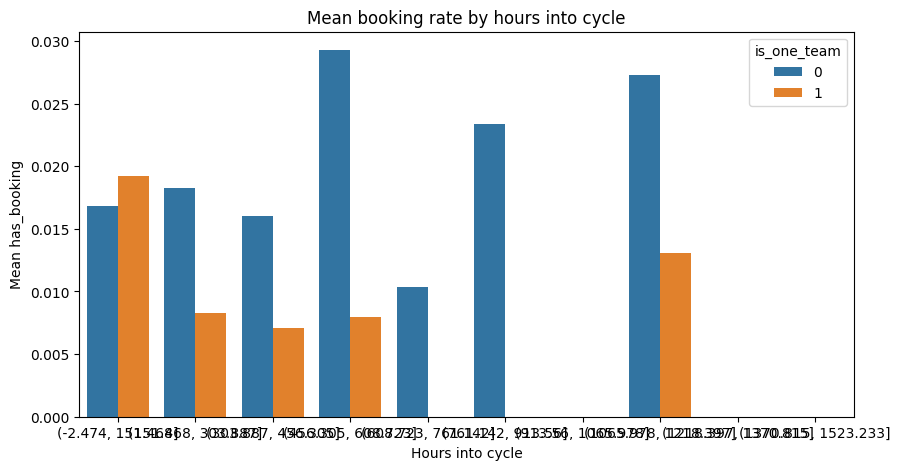

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

hour_bin = pd.cut(df["hours_into_cycle"],bins=10)
df = df.assign(hours_bin=hour_bin)
hours_into_share = df.groupby(['is_one_team',"hours_bin"])["has_booking"].mean().reset_index()
print(hours_into_share)

print(hours_into_share)
plt.figure(figsize=(10,5))
sns.barplot(data=hours_into_share,x="hours_bin", y="has_booking",hue="is_one_team")
plt.xlabel("Hours into cycle")
plt.ylabel("Mean has_booking")
plt.title("Mean booking rate by hours into cycle")
plt.show()

In [57]:
one_team_count = df["is_one_team"].value_counts(normalize=True)
print(one_team_count)



is_one_team
0    0.674648
1    0.325352
Name: proportion, dtype: float64


In [58]:
team_count= df.groupby(["is_one_team"])["has_booking"].mean()
print(team_count)


is_one_team
0    0.017836
1    0.011768
Name: has_booking, dtype: float64


In [59]:
class_count = df["class_type"].value_counts(normalize=True)
print(class_count)

class_type
1    0.641466
0    0.358534
Name: proportion, dtype: float64


In [60]:
class_count= df.groupby(["class_type"])["has_booking"].mean()
print(class_count)

class_type
0    0.011526
1    0.018285
Name: has_booking, dtype: float64


In [61]:
customer = df.drop_duplicates(["username"])[["is_one_team"]].value_counts()
print(customer)

is_one_team
0              25
1              12
Name: count, dtype: int64


In [62]:
heatmap = df.groupby(["polling_dow","polling_hour"])["has_booking"].mean().reset_index()

In [63]:
heatmap

,polling_dow,polling_hour,has_booking
0,0,0,0.000000
1,0,1,0.000000
2,0,2,0.000000
3,0,3,0.000000
4,0,4,0.000000
...,...,...,...
163,6,19,0.005291
164,6,20,0.000000
165,6,21,0.005291
166,6,22,0.010582


In [64]:
pv = pd.pivot(data=heatmap,index="polling_hour",columns="polling_dow",values="has_booking")

<Axes: xlabel='polling_dow', ylabel='polling_hour'>

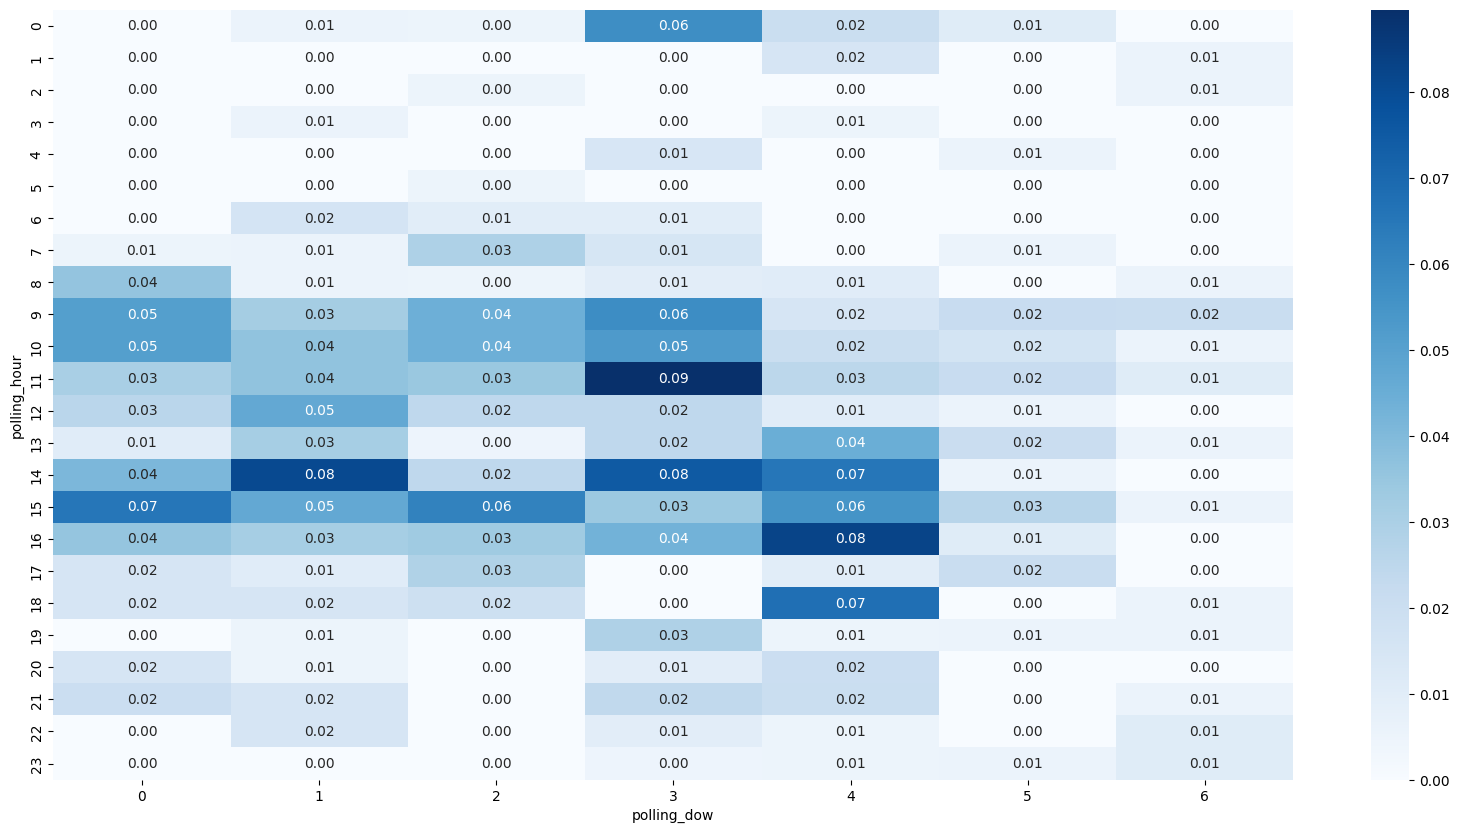

In [65]:
fig,ax = plt.subplots(figsize=(20,10))
sns.heatmap(pv,annot=True,fmt=".2f",cmap="Blues")

      username               cycle_start                 cycle_end  \
0       addity 2025-08-13 21:00:00+08:00 2025-08-28 11:36:00+08:00   
22386  lucinda 2025-08-16 13:55:00+08:00 2025-08-28 19:00:00+08:00   
23537     matt 2025-08-12 01:21:00+08:00 2025-09-23 23:52:00+08:00   
24148      max 2025-09-24 00:00:00+08:00 2025-09-25 23:59:00+08:00   
25853    natar 2025-10-16 00:00:00+08:00 2025-10-17 23:59:00+08:00   
24227      mya 2025-10-29 16:15:00+08:00 2025-11-01 23:59:00+08:00   
28199     ryan 2025-11-01 21:30:00+08:00 2025-11-03 23:59:00+08:00   
31870   tomato 2025-11-26 11:00:00+08:00 2025-11-27 23:59:00+08:00   
27200     phuc 2025-12-30 16:00:00+08:00 2026-01-01 23:59:00+08:00   
27169  pakning 2026-01-20 17:00:00+08:00 2026-01-26 23:59:00+08:00   
996        ali 2026-02-06 10:00:00+08:00 2026-02-25 23:59:00+08:00   
9545     faith 2026-02-27 00:00:00+08:00 2026-03-09 23:59:00+08:00   

       cycle_duration  
0          350.600000  
22386      293.083333  
23537     1030.51

<Axes: ylabel='cycle_duration'>

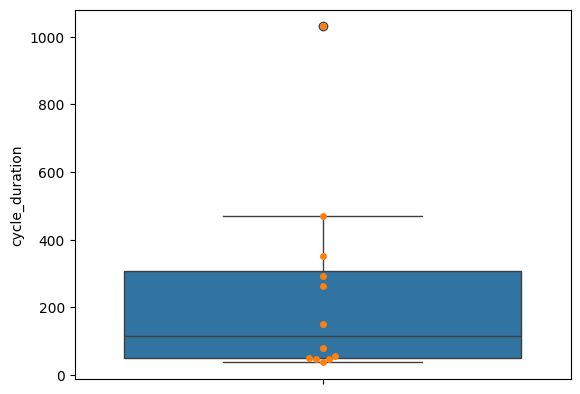

In [66]:
ot_customers = df.loc[df["is_one_team"]==1].sort_values("cycle_end").drop_duplicates(subset=["username"],keep="first")[["username","cycle_start","cycle_end"]]
ot_customers["cycle_duration"] = (ot_customers["cycle_end"] - ot_customers["cycle_start"]).dt.total_seconds()/3600
print(ot_customers)
sns.boxplot(data=ot_customers,y="cycle_duration")
sns.swarmplot(data=ot_customers,y="cycle_duration")

Overall base rate: 0.0159


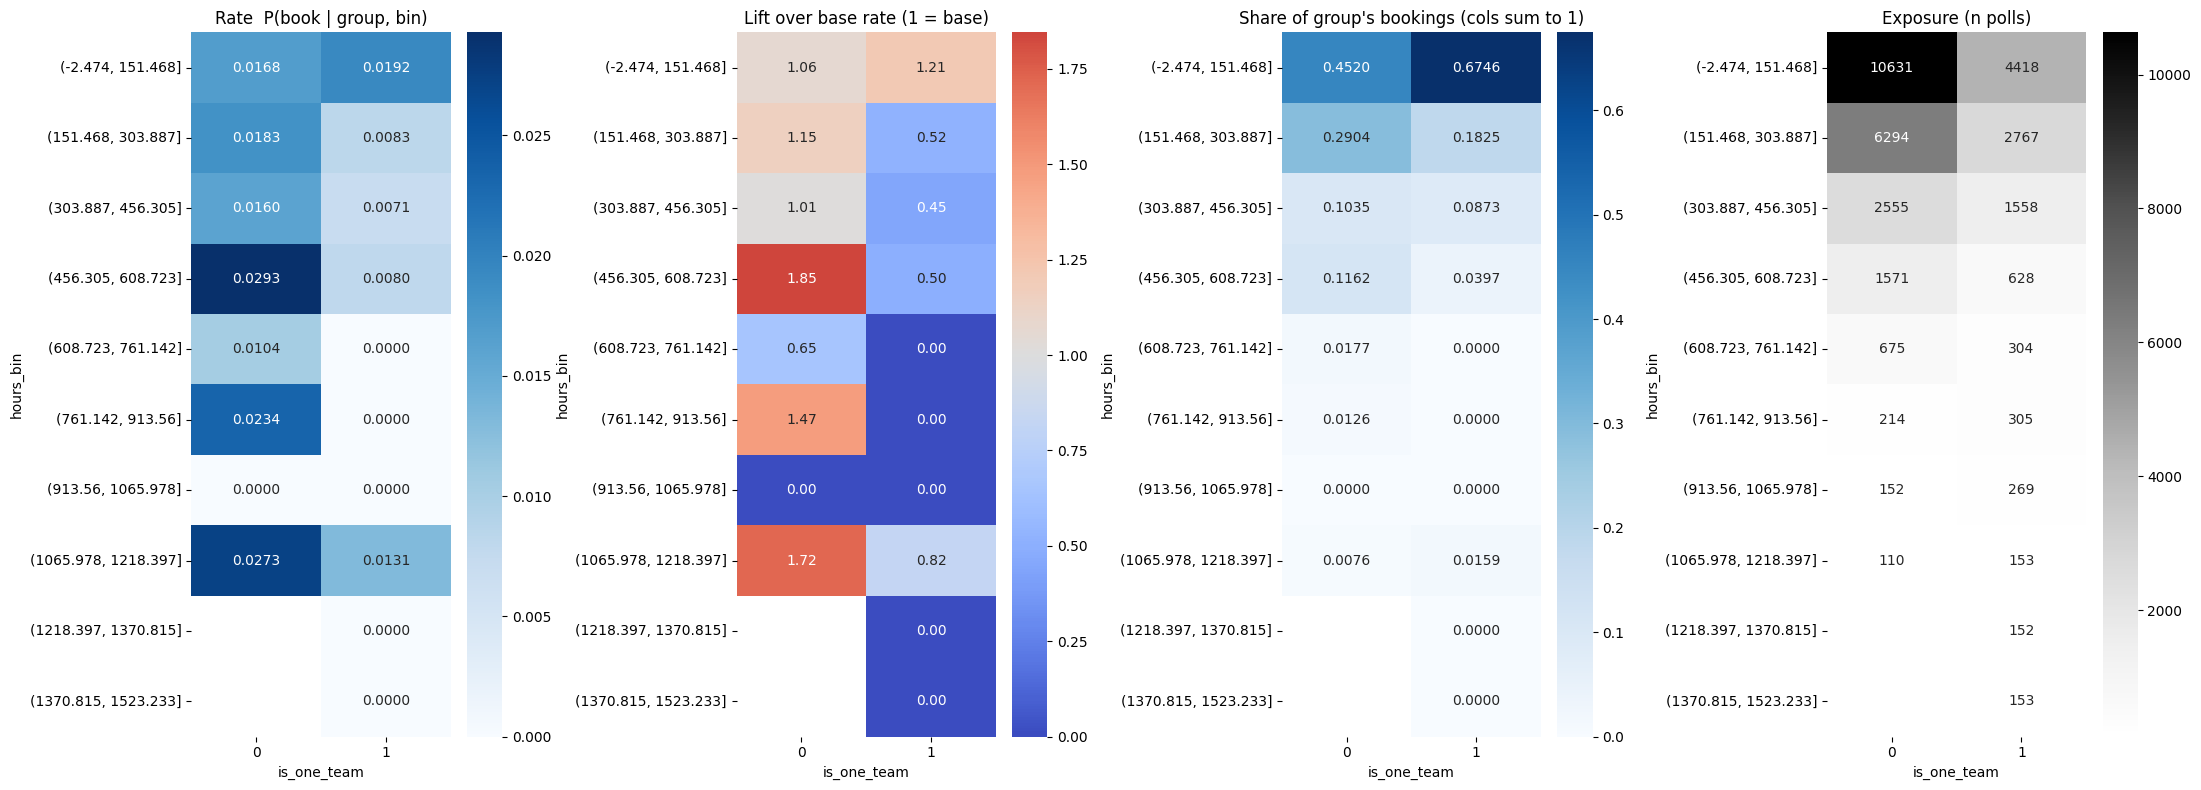

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

base_rate = df["has_booking"].mean()
print(f"Overall base rate: {base_rate:.4f}")

# one pass, all aggregates
g = (df.groupby(["is_one_team", "hours_bin"])["has_booking"]
       .agg(n_polls="count", n_bookings="sum", rate="mean")
       .reset_index())

# within-group totals for normalization
grp_bookings = df.groupby("is_one_team")["has_booking"].sum()

# share of THIS GROUP's bookings landing in this bin -> columns sum to ~1 -> tests concentration
g["share_of_group_bookings"] = g["n_bookings"] / g["is_one_team"].map(grp_bookings)
# multiplicative lift over base rate -> reads signal strength, not absolute smallness
g["lift"] = g["rate"] / base_rate

def pv(col):
    return pd.pivot(g, index="hours_bin", columns="is_one_team", values=col)

fig, axes = plt.subplots(1, 4, figsize=(22, 8))

sns.heatmap(pv("rate"), annot=True, fmt=".4f", cmap="Blues", ax=axes[0])
axes[0].set_title("Rate  P(book | group, bin)")

sns.heatmap(pv("lift"), annot=True, fmt=".2f", cmap="coolwarm", center=1, ax=axes[1])
axes[1].set_title("Lift over base rate (1 = base)")

sns.heatmap(pv("share_of_group_bookings"), annot=True, fmt=".4f", cmap="Blues", ax=axes[2])
axes[2].set_title("Share of group's bookings (cols sum to 1)")

sns.heatmap(pv("n_polls"), annot=True, fmt=".0f", cmap="Greys", ax=axes[3])
axes[3].set_title("Exposure (n polls)")

plt.tight_layout()
plt.show()